In [158]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import math



In [159]:
train_df = pd.read_csv("Datast/train.csv")
test_df = pd.read_csv("Datast/test.csv")
building_df = pd.read_csv("Datast/building_metadata.csv")
weather_train_df = pd.read_csv("Datast/weather_train.csv")
weather_test_df = pd.read_csv("Datast/weather_test.csv")

In [160]:
wet_cop=weather_train_df.copy()
buil_cop=building_df.copy()

In [161]:
missing_percentage = buil_cop.isnull().sum() / len(buil_cop) * 100
print(missing_percentage.sort_values(ascending=False))
# buil_cop.hist(bins=50,figsize=(20,18))

floor_count    75.500345
year_built     53.416149
building_id     0.000000
site_id         0.000000
square_feet     0.000000
primary_use     0.000000
dtype: float64


In [162]:
buil_cop["age"]=2019-buil_cop['year_built']
buil_cop.drop(columns='year_built',inplace=True)

In [163]:
# plt.figure(figsize=(12, 6))
# sns.boxplot(x="site_id", y="age", data=buil_cop)
# plt.title("Building Age Distribution by Site ID")
# plt.xlabel("Site ID")
# plt.ylabel("Building Age")
# plt.xticks(rotation=45)
# plt.show()
for i in range(16):
    print(((buil_cop[buil_cop['site_id']==i])['age'].isna().sum()/len((buil_cop[buil_cop['site_id']==i])['age'])*100),i)

0.0 0
21.568627450980394 1
30.37037037037037 2
51.82481751824818 3
2.197802197802198 4
1.1235955056179776 5
100.0 6
6.666666666666667 7
100.0 8
100.0 9
100.0 10
100.0 11
100.0 12
100.0 13
100.0 14
8.870967741935484 15


In [164]:
# Step 1: Calculate missing value percentage for "age" in each site_id
missing_percent_per_site = buil_cop.groupby("site_id")["age"].apply(lambda x: x.isna().mean() * 100)

# Step 2: Identify site_ids where missing values in "age" are <10%
valid_sites = missing_percent_per_site[missing_percent_per_site < 10].index

# Step 3: Fill NA values in "age" for those site_ids with the mean of "age" per site_id
buil_cop.loc[buil_cop["site_id"].isin(valid_sites), "age"] = (
    buil_cop.loc[buil_cop["site_id"].isin(valid_sites)]
    .groupby("site_id")["age"]
    .transform(lambda x: x.fillna(x.mean()))
)

# # Step 4: Check if it worked
# print(buil_cop["age"].isna().sum())  # Should show remaining NaNs only for sites with >10% missing
# valid_sites

In [165]:
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error
# import numpy as np

# # Prepare data: Keep rows where age is not null for training
# train_data = buil_cop.dropna(subset=["age"])
# test_data = buil_cop[buil_cop["age"].isna()]

# # Select features that might predict age
# features = ["square_feet_log", "type_enc"]
# X_train = train_data[features]
# y_train = train_data["age"]

# # Train a simple model
# model = LinearRegression()
# model.fit(X_train, y_train)

# # Calculate MSE on training data
# y_pred_train = model.predict(X_train)
# mse_train = mean_squared_error(y_train, y_pred_train)
# print(f"Training MSE: {mse_train}")

# # If you want to do cross-validation for more reliable evaluation:
# from sklearn.model_selection import cross_val_score
# cv_scores = cross_val_score(model, X_train, y_train, 
#                           scoring='neg_mean_squared_error', cv=5)
# print(f"Cross-validated MSE: {-cv_scores.mean()}")

# # Predict missing ages
# buil_cop.loc[buil_cop["age"].isna(), "age"] = model.predict(test_data[features])

In [166]:
# cols = buil_cop.columns.tolist()
# for col in cols:
#     plt.figure(figsize=(8, 6))
#     sns.boxplot(x=wet_cop[col])
#     plt.title(f"Boxplot of {col}")
#     plt.show()

# cols

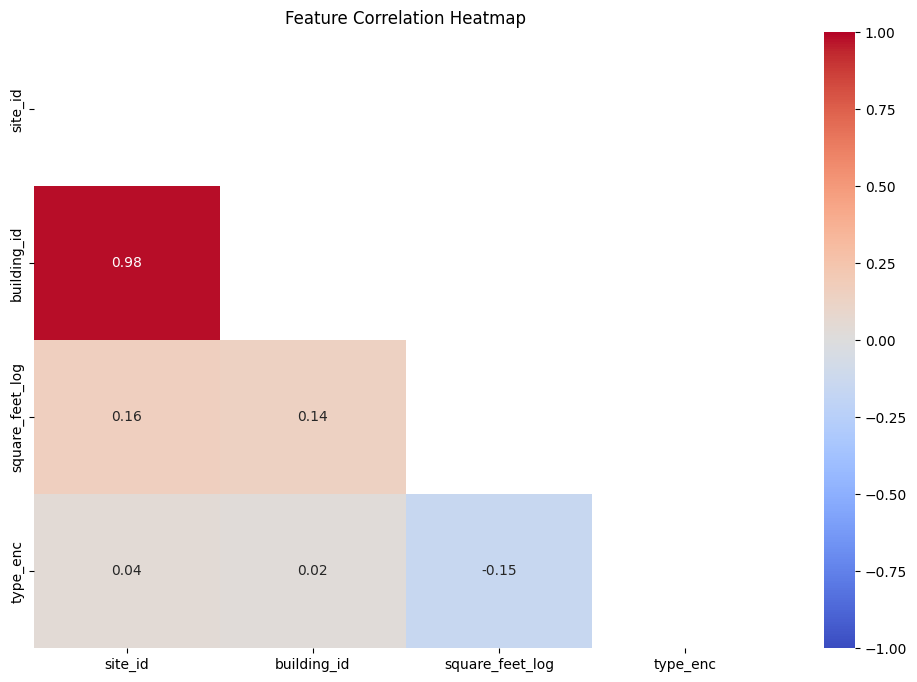

In [180]:
numeric_cols = buil_cop.select_dtypes(include=['float64', 'int64']).columns
corr_df = buil_cop[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    mask=np.triu(np.ones_like(corr_df))  # Hide upper triangle for clarity
)
plt.title("Feature Correlation Heatmap")
plt.show()

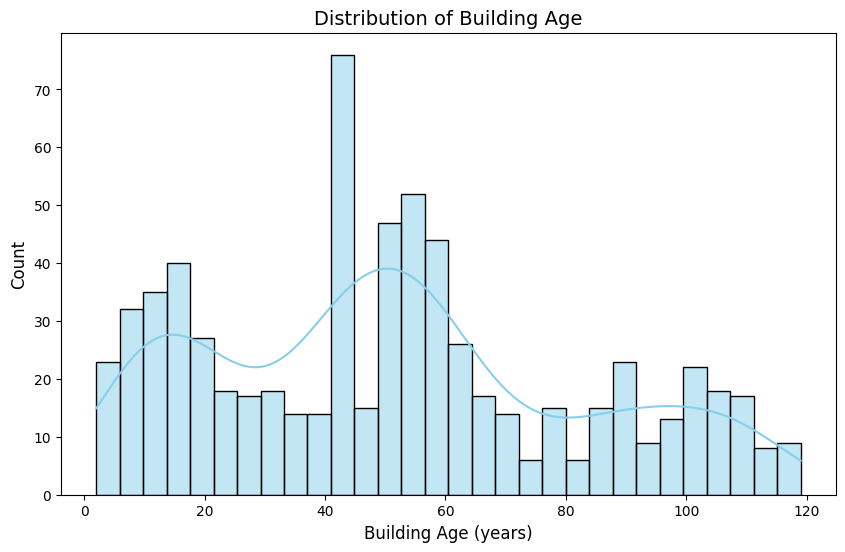

In [168]:
plt.figure(figsize=(10, 6))

# Create histogram
sns.histplot(buil_cop["age"], bins=30, kde=True, color="skyblue")

# Labels and title
plt.xlabel("Building Age (years)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of Building Age", fontsize=14)

# Show the plot
plt.show()

In [169]:
xyz=buil_cop.copy()

In [170]:
missing_percentage = xyz.isnull().sum() / len(xyz) * 100
print(missing_percentage.sort_values(ascending=False))
# xyz.hist(bins=50,figsize=(20,18))

floor_count    75.500345
age            52.380952
building_id     0.000000
site_id         0.000000
square_feet     0.000000
primary_use     0.000000
dtype: float64


In [171]:
# xyz["age"] = xyz["age"].fillna(xyz.groupby("site_id")["age"].transform("mean"))
# xyz["age"].fillna(xyz.groupby("primary_use")["age"].transform("mean"),inplace=True)


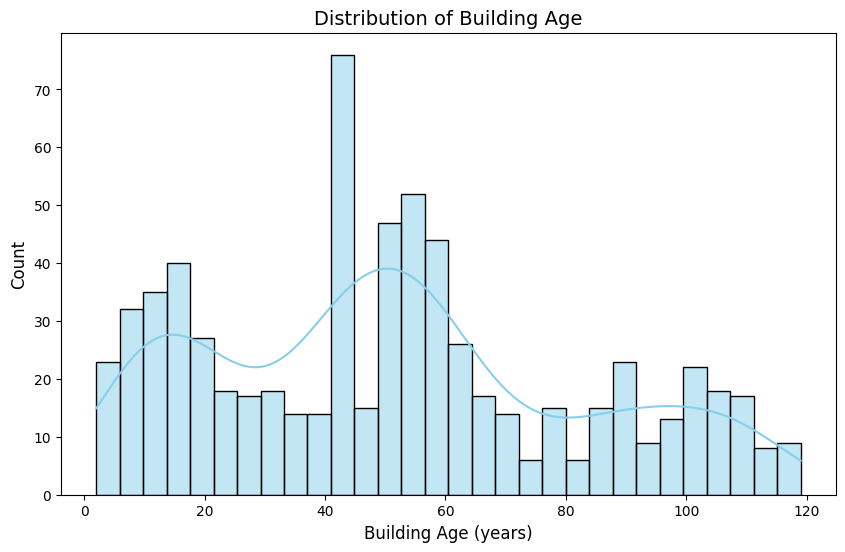

In [172]:
plt.figure(figsize=(10, 6))

# Create histogram
sns.histplot(xyz["age"], bins=30, kde=True, color="skyblue")

# Labels and title
plt.xlabel("Building Age (years)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of Building Age", fontsize=14)

# Show the plot
plt.show()

In [173]:
buil_cop['square_feet_log'] = np.log1p(buil_cop['square_feet'])
# buil_cop['square_feet']
buil_cop['square_feet_log']

0        8.913685
1        7.908755
2        8.589886
3       10.072639
4       11.666573
          ...    
1444     9.884305
1445     8.366138
1446     9.329545
1447    10.301458
1448    11.432496
Name: square_feet_log, Length: 1449, dtype: float64

In [174]:
label_encoder = LabelEncoder()

# Apply label encoding to the 'Category' column
buil_cop['type_enc'] = label_encoder.fit_transform(buil_cop['primary_use'])
# buil_cop['type_enc'].unique()


In [177]:
# buil_cop.drop(columns=['primary_use','square_feet','floor_count','age'],inplace=True)

In [ ]:
# # wet_cop['site_id'].unique()
# # buil_cop[['floor_count','building_id']]
# for i in range(1450):
#     x=buil_cop[buil_cop['building_id']==i]
#     print(x['floor_count'].value_counts(),x['building_id'].unique(),x['site_id'].unique())

In [179]:
# label_encoder = LabelEncoder()

# # Apply label encoding to the 'Category' column
# buil_cop['type_enc'] = label_encoder.fit_transform(buil_cop['primary_use'])
# # buil_cop['type_enc'].unique()


In [181]:
train_df.shape

(20216100, 4)

In [182]:
train_df.isnull().sum()

building_id      0
meter            0
timestamp        0
meter_reading    0
dtype: int64

In [ ]:
buil_cop['age']=2019-buil_cop['year_built']
plt.figure(figsize=(8,5))
sns.boxplot(x='site_id', y='age', data=buil_cop)
plt.title("Building Age Distribution by Site")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='type_enc', y='age', data=buil_cop)
plt.title("Building Age Distribution by type")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='floor_count', y='type_enc', data=buil_cop)
plt.title("Building Age Distribution by floorcount")
plt.show()

In [ ]:
# xyz['age']=2019-xyz['year_built']
plt.figure(figsize=(8,5))
sns.boxplot(x='site_id', y='age', data=xyz)
plt.title("Building Age Distribution by Site")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='type_enc', y='age', data=xyz)
plt.title("Building Age Distribution by type")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='floor_count', y='type_enc', data=xyz)
plt.title("Building Age Distribution by floorcount")
plt.show()